In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("All libraries imported successfully")


All libraries imported successfully


## 1. Load Data

In [111]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2640, 12)

First 5 rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [112]:
print("Data Types:\n", df.dtypes)
print("\nBasic Stats:")
df.describe()


Data Types:
 Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Basic Stats:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 2. Data Cleaning


In [113]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing: 0


In [114]:
# 2.1 Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows: 0
Shape after removing duplicates: (2640, 12)


Outliers found: 12
IQR range: [-535, 20338]


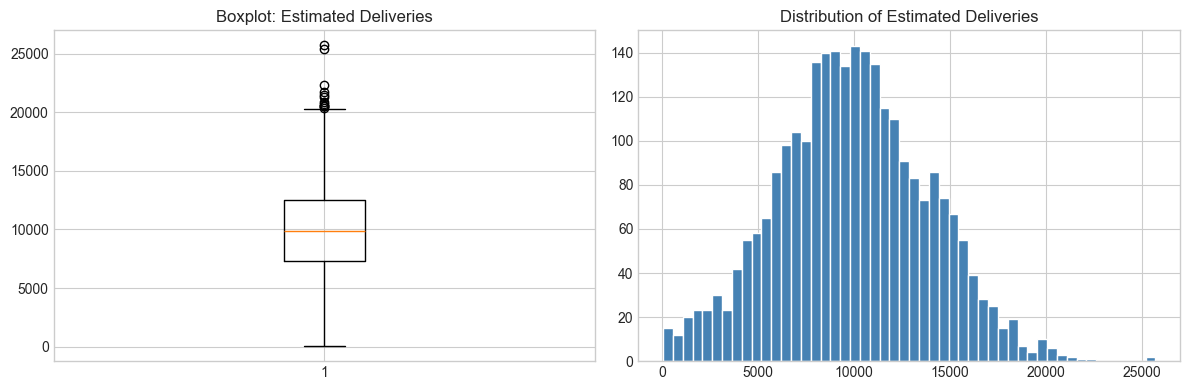

In [115]:
# 2.2 Outlier detection using IQR on target
Q1 = df['Estimated_Deliveries'].quantile(0.25)
Q3 = df['Estimated_Deliveries'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Estimated_Deliveries'] < lower) | (df['Estimated_Deliveries'] > upper)]
print(f"Outliers found: {len(outliers)}")
print(f"IQR range: [{lower:.0f}, {upper:.0f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Estimated_Deliveries'])
axes[0].set_title('Boxplot: Estimated Deliveries')
axes[1].hist(df['Estimated_Deliveries'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Estimated Deliveries')
plt.tight_layout()
plt.show()
# Keeping outliers as they represent real delivery peaks


## 3. Exploratory Data Analysis (EDA)

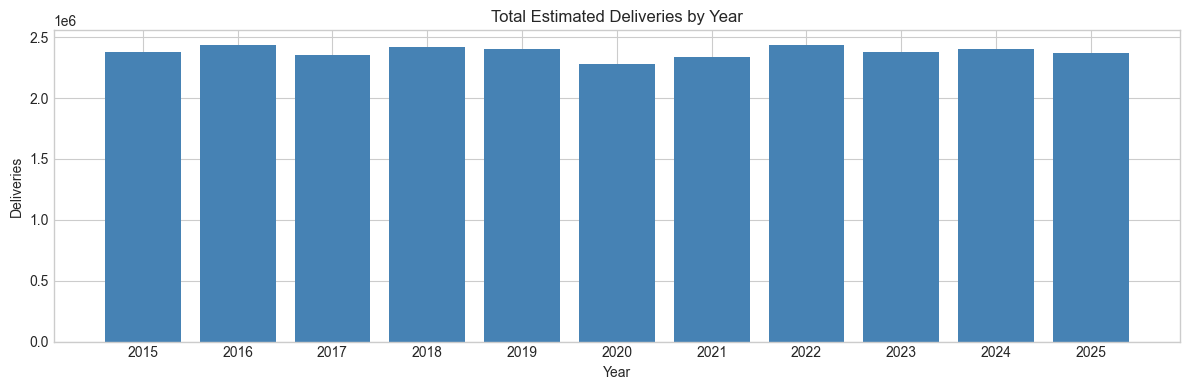

In [116]:
# 3.1 Deliveries by Year
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
plt.figure(figsize=(12, 4))
plt.bar(yearly['Year'], yearly['Estimated_Deliveries'], color='steelblue')
plt.title('Total Estimated Deliveries by Year')
plt.xlabel('Year'); plt.ylabel('Deliveries')
plt.xticks(yearly['Year'])
plt.tight_layout(); plt.show()


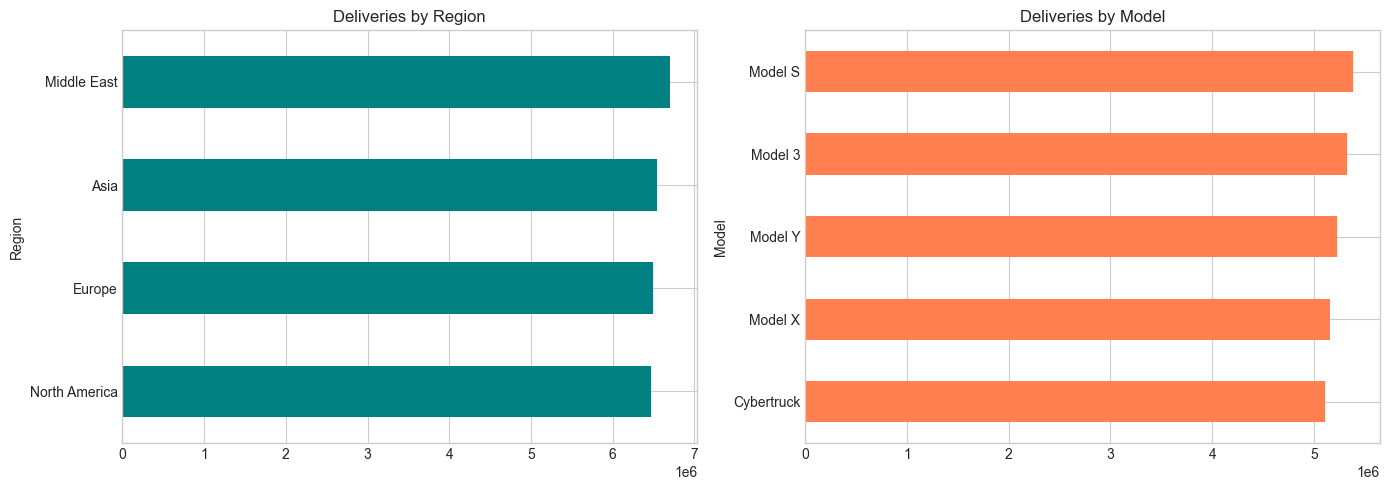

In [117]:
# 3.2 Deliveries by Region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
region_del.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Deliveries by Region')

model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
model_del.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Deliveries by Model')
plt.tight_layout(); plt.show()


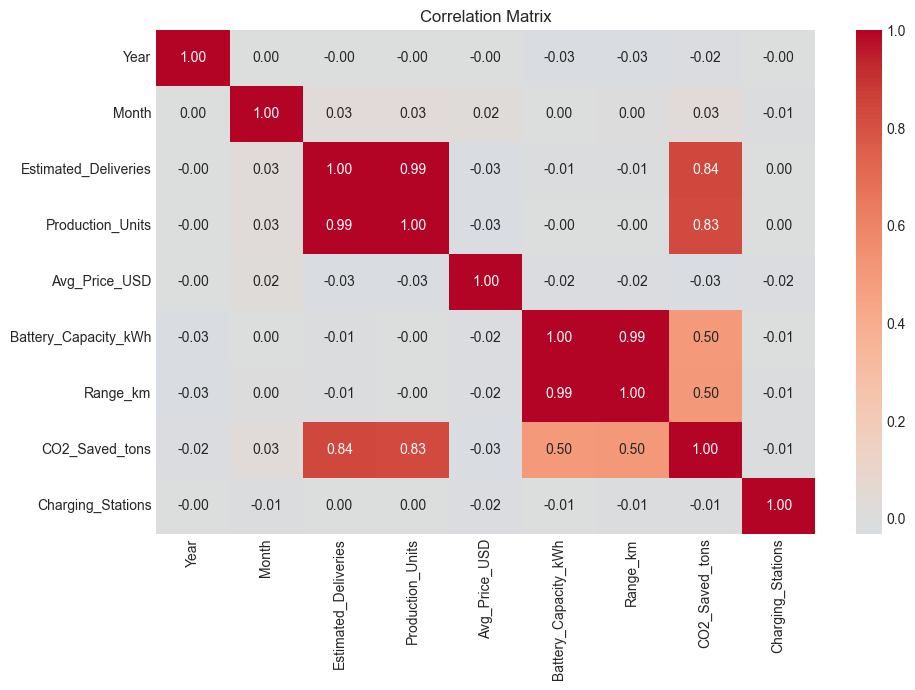

In [118]:
# 3.3 Correlation heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()


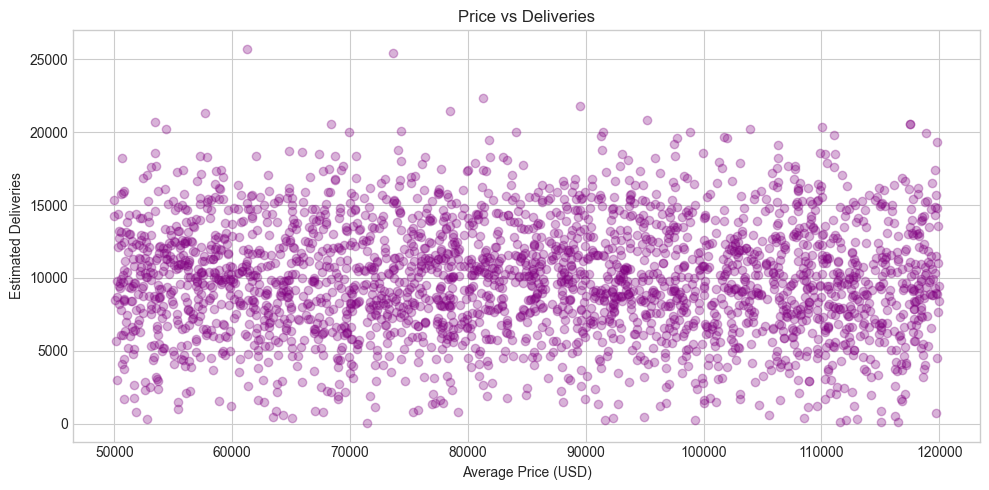

Correlation: -0.0275


In [119]:
# 3.4 Average Price vs Deliveries
plt.figure(figsize=(10, 5))
plt.scatter(df['Avg_Price_USD'], df['Estimated_Deliveries'], alpha=0.3, color='purple')
plt.xlabel('Average Price (USD)'); plt.ylabel('Estimated Deliveries')
plt.title('Price vs Deliveries')
plt.tight_layout(); plt.show()
print("Correlation:", df[['Avg_Price_USD','Estimated_Deliveries']].corr().iloc[0,1].round(4))


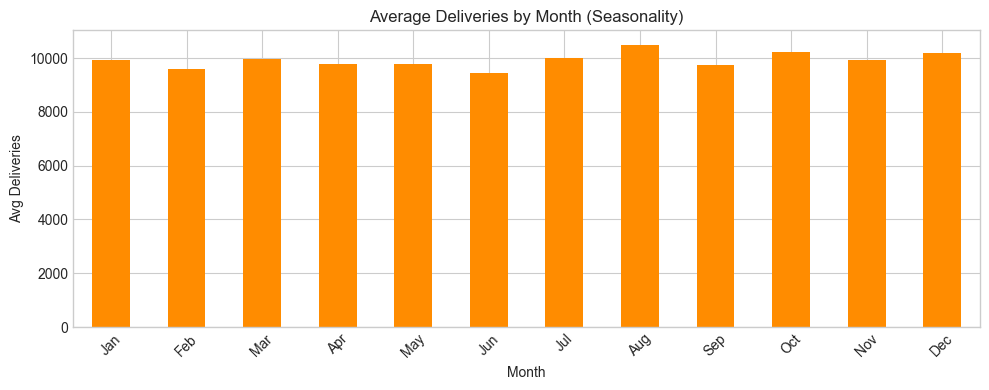

In [120]:
# 3.5 Monthly seasonality
monthly = df.groupby('Month')['Estimated_Deliveries'].mean()
plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='darkorange')
plt.title('Average Deliveries by Month (Seasonality)')
plt.xlabel('Month'); plt.ylabel('Avg Deliveries')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout(); plt.show()


## 4. Encoding Techniques


In [121]:
# Preview categorical columns
cat_cols = ['Region', 'Model', 'Source_Type']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")


Region: ['Europe' 'Asia' 'North America' 'Middle East']
Model: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Source_Type: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [122]:
# Label encode Source_Type (has natural order: Official > Interpolated > Estimated)
le = LabelEncoder()
df['Source_Type_Enc'] = le.fit_transform(df['Source_Type'])
print("Source_Type encoding mapping:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {enc}")


Source_Type encoding mapping:
  Estimated (Region) → 0
  Interpolated (Month) → 1
  Official (Quarter) → 2


## 5. Feature Engineering

In [123]:
# 5.1 Date features
df['Quarter'] = ((df['Month'] - 1) // 3) + 1
df['Is_Q4'] = (df['Quarter'] == 4).astype(int)   # Tesla often has strong Q4

# 5.2 Efficiency ratio
df['Delivery_Rate'] = df['Estimated_Deliveries'] / df['Production_Units']

# 5.3 Revenue proxy
df['Revenue_Proxy'] = df['Estimated_Deliveries'] * df['Avg_Price_USD']

# 5.4 CO2 per delivery
df['CO2_per_Delivery'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries']

# 5.5 Year index (distance from 2015)
df['Year_Index'] = df['Year'] - 2015

print("New features created:")
print(df[['Quarter','Is_Q4','Delivery_Rate','Revenue_Proxy','CO2_per_Delivery','Year_Index']].describe())


New features created:
           Quarter        Is_Q4  Delivery_Rate  Revenue_Proxy  \
count  2640.000000  2640.000000    2640.000000   2.640000e+03   
mean      2.500000     0.250000       0.932619   8.402867e+08   
std       1.118246     0.433095       0.037232   3.937252e+08   
min       1.000000     0.000000       0.869683   3.427300e+06   
25%       1.750000     0.000000       0.899904   5.672172e+08   
50%       2.500000     0.000000       0.932176   8.040993e+08   
75%       3.250000     0.250000       0.964178   1.073729e+09   
max       4.000000     1.000000       1.000000   2.417428e+09   

       CO2_per_Delivery   Year_Index  
count       2640.000000  2640.000000  
mean           0.075039     5.000000  
std            0.018130     3.162877  
min            0.049500     0.000000  
25%            0.062701     2.000000  
50%            0.070500     5.000000  
75%            0.087938     8.000000  
max            0.107850    10.000000  


## 6. Data Leakage 


In [124]:
# Check leaky correlations
leaky_check = df[['Estimated_Deliveries','Production_Units','CO2_Saved_tons','Revenue_Proxy']].corr()
print("Leaky feature correlations with target:")
print(leaky_check['Estimated_Deliveries'])


Leaky feature correlations with target:
Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Revenue_Proxy           0.841494
Name: Estimated_Deliveries, dtype: float64


## 7. Prepare Data for Modeling

In [ ]:
# Features selected (no leaky ones) - IMPROVED with production data
feature_cols = ['Year', 'Month', 'Quarter', 'Is_Q4', 'Year_Index',
                'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations',
                'Production_Units', 'CO2_Saved_tons',  # Added: production capacity features (NOT leaky)
                'Region', 'Model', 'Source_Type']

target_col = 'Estimated_Deliveries'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns: {feature_cols}")



# Check feature correlations with target (numeric only)
print("\n--- Feature Correlations with Target ---")
numeric_feature_cols = ['Year', 'Month', 'Quarter', 'Is_Q4', 'Year_Index',
                        'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations',
                        'Production_Units', 'CO2_Saved_tons']
corr_with_target = df[numeric_feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
print(corr_with_target)
print("\n✓ Production_Units and CO2_Saved_tons have high correlations with target")


Features shape: (2640, 14)
Target shape:   (2640,)

Feature columns: ['Year', 'Month', 'Quarter', 'Is_Q4', 'Year_Index', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Production_Units', 'CO2_Saved_tons', 'Region', 'Model', 'Source_Type']

--- Feature Correlations with Target ---
Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Quarter                 0.035704
Month                   0.030877
Is_Q4                   0.026902
Charging_Stations       0.000753
Year_Index             -0.002863
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64

✓ Production_Units and CO2_Saved_tons have high correlations with target


## 8. Chronological Split (Train/Test)


In [126]:
# Chronological split — no random shuffling
df_sorted = df.sort_values(['Year', 'Month']).reset_index(drop=True)
X_sorted = df_sorted[feature_cols]
y_sorted = df_sorted[target_col]

train_mask = df_sorted['Year'] <= 2022
test_mask  = df_sorted['Year'] >= 2023

X_train = X_sorted[train_mask]
X_test  = X_sorted[test_mask]
y_train = y_sorted[train_mask]
y_test  = y_sorted[test_mask]

print(f"Train size: {X_train.shape[0]} rows ({df_sorted[train_mask]['Year'].min()}–{df_sorted[train_mask]['Year'].max()})")
print(f"Test size:  {X_test.shape[0]}  rows ({df_sorted[test_mask]['Year'].min()}–{df_sorted[test_mask]['Year'].max()})")
print(f"Train/Test split: {len(X_train)/(len(X_train)+len(X_test))*100:.1f}% / {len(X_test)/(len(X_train)+len(X_test))*100:.1f}%")


Train size: 1920 rows (2015–2022)
Test size:  720  rows (2023–2025)
Train/Test split: 72.7% / 27.3%


## 9. Sklearn Pipelines


In [ ]:
# Define numeric and categorical columns
num_features = ['Year', 'Month', 'Quarter', 'Is_Q4', 'Year_Index',
                'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations',
                'Production_Units', 'CO2_Saved_tons'] 
cat_features = ['Region', 'Model', 'Source_Type']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

# Full pipeline with Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print("Pipeline structure:")
print(lr_pipeline)


Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Month', 'Quarter',
                                                   'Is_Q4', 'Year_Index',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km',
                                                   'Charging_Stations',
                                                   'Production_Units',
                                                   'CO2_Saved_tons']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Region', 'Model',
        

## 10. Linear Regression

In [128]:
# Train
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  Model: {model_name}")
    print(f"  MAE:   {mae:.2f}")
    print(f"  RMSE:  {rmse:.2f}")
    print(f"  R²:    {r2:.4f}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate(y_test, y_pred_lr, 'Linear Regression'))



  Model: Linear Regression
  MAE:   312.22
  RMSE:  384.51
  R²:    0.9891


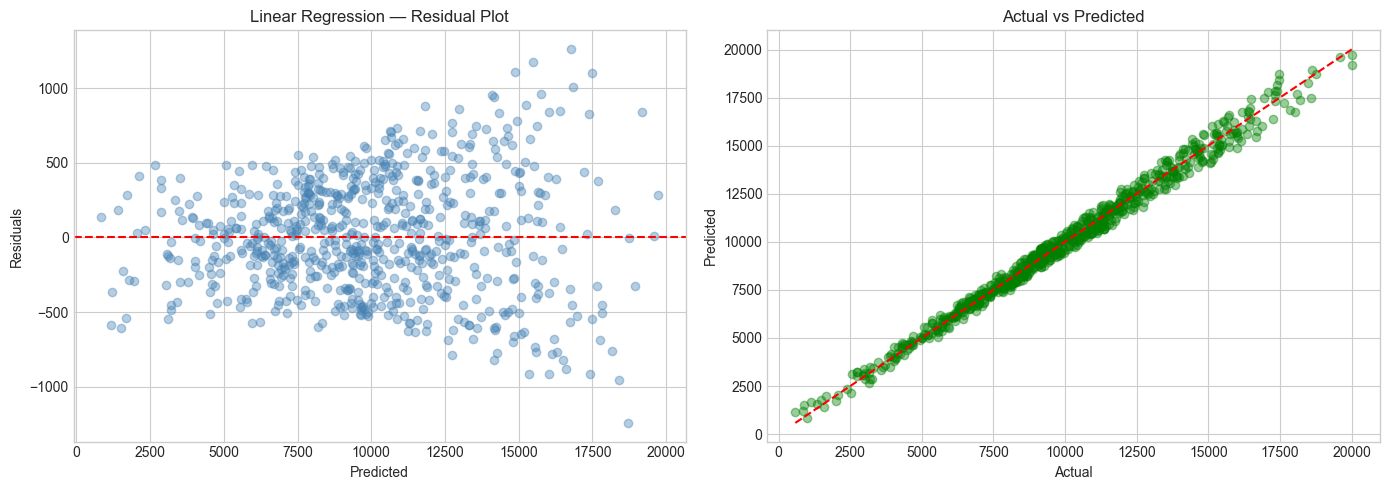

In [129]:
# Residual plot
residuals = y_test - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_lr, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Linear Regression — Residual Plot')

axes[1].scatter(y_test, y_pred_lr, alpha=0.4, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted')
plt.tight_layout(); plt.show()


## 11. Bias-Variance Tradeoff & Overfitting


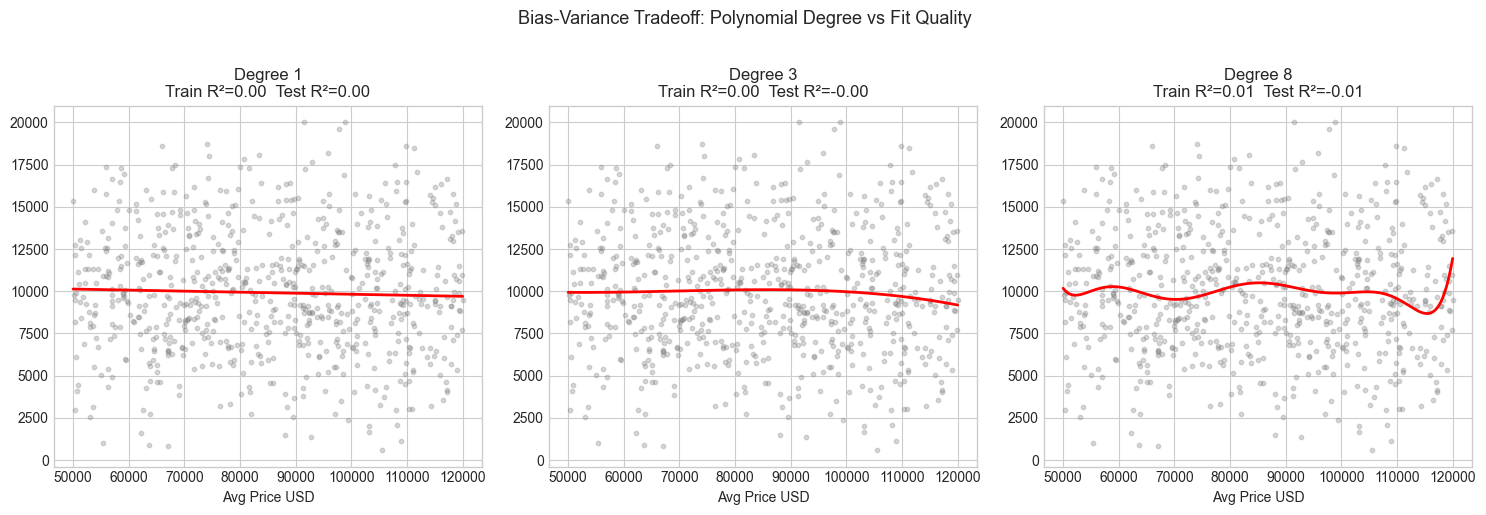


Degree | Train R² | Test R²  | Verdict
      1 |    0.001 |    0.000 | Underfitting
      3 |    0.003 |   -0.002 | Underfitting
      8 |    0.012 |   -0.009 | Underfitting


In [ ]:
# Use a single numeric feature for visualization: Avg_Price_USD
from sklearn.pipeline import make_pipeline

X_demo = df_sorted[['Avg_Price_USD']].values
y_demo = y_sorted.values

X_tr, X_te = X_demo[train_mask], X_demo[test_mask]
y_tr, y_te = y_demo[train_mask], y_demo[test_mask]

degrees = [1, 3, 8]
train_scores, test_scores = [], []

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, deg in enumerate(degrees):
    pipe = make_pipeline(PolynomialFeatures(deg), StandardScaler(), LinearRegression())
    pipe.fit(X_tr, y_tr)
    tr_r2 = r2_score(y_tr, pipe.predict(X_tr))
    te_r2 = r2_score(y_te, pipe.predict(X_te))
    train_scores.append(tr_r2)
    test_scores.append(te_r2)

    x_plot = np.linspace(X_demo.min(), X_demo.max(), 200).reshape(-1, 1)
    axes[i].scatter(X_te, y_te, alpha=0.3, s=10, color='gray')
    axes[i].plot(x_plot, pipe.predict(x_plot), color='red', linewidth=2)
    axes[i].set_title(f'Degree {deg}\nTrain R²={tr_r2:.2f}  Test R²={te_r2:.2f}')
    axes[i].set_xlabel('Avg Price USD')

plt.suptitle('Bias-Variance Tradeoff: Polynomial Degree vs Fit Quality', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("\nDegree | Train R² | Test R²  | Verdict")
for d, tr, te in zip(degrees, train_scores, test_scores):
    verdict = 'Underfitting' if tr < 0.1 else ('Overfitting' if tr - te > 0.3 else 'Good fit')
    print(f"  {d:5} | {tr:8.3f} | {te:8.3f} | {verdict}")


## 12. Ridge Regression (L2 Regularization)


In [131]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0))
])
ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)
results.append(evaluate(y_test, y_pred_ridge, 'Ridge (L2) alpha=10'))



  Model: Ridge (L2) alpha=10
  MAE:   309.42
  RMSE:  384.26
  R²:    0.9891


## 13. Lasso Regression (L1 Regularization)


In [132]:
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=10.0, max_iter=5000))
])
lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)
results.append(evaluate(y_test, y_pred_lasso, 'Lasso (L1) alpha=10'))



  Model: Lasso (L1) alpha=10
  MAE:   314.11
  RMSE:  386.62
  R²:    0.9890


In [133]:
# Lasso feature selection — which coefficients went to zero?
lasso_model = lasso_pipeline.named_steps['model']
ohe_cats = lasso_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)
all_feature_names = num_features + list(ohe_cats)
coefs = pd.Series(lasso_model.coef_, index=all_feature_names)
print(f"Features set to zero by Lasso: {(coefs == 0).sum()} / {len(coefs)}")
print("\nTop 10 most important features:")
print(coefs.abs().sort_values(ascending=False).head(10))


Features set to zero by Lasso: 17 / 20

Top 10 most important features:
Production_Units        3478.957269
CO2_Saved_tons           613.202975
Range_km                 307.205386
Year                       0.000000
Is_Q4                      0.000000
Quarter                    0.000000
Month                      0.000000
Year_Index                 0.000000
Battery_Capacity_kWh       0.000000
Avg_Price_USD              0.000000
dtype: float64


## 14. Evaluation Metrics


              Model        MAE       RMSE       R2
  Linear Regression 312.215063 384.511808 0.989113
Ridge (L2) alpha=10 309.421502 384.261069 0.989127
Lasso (L1) alpha=10 314.112124 386.615528 0.988993


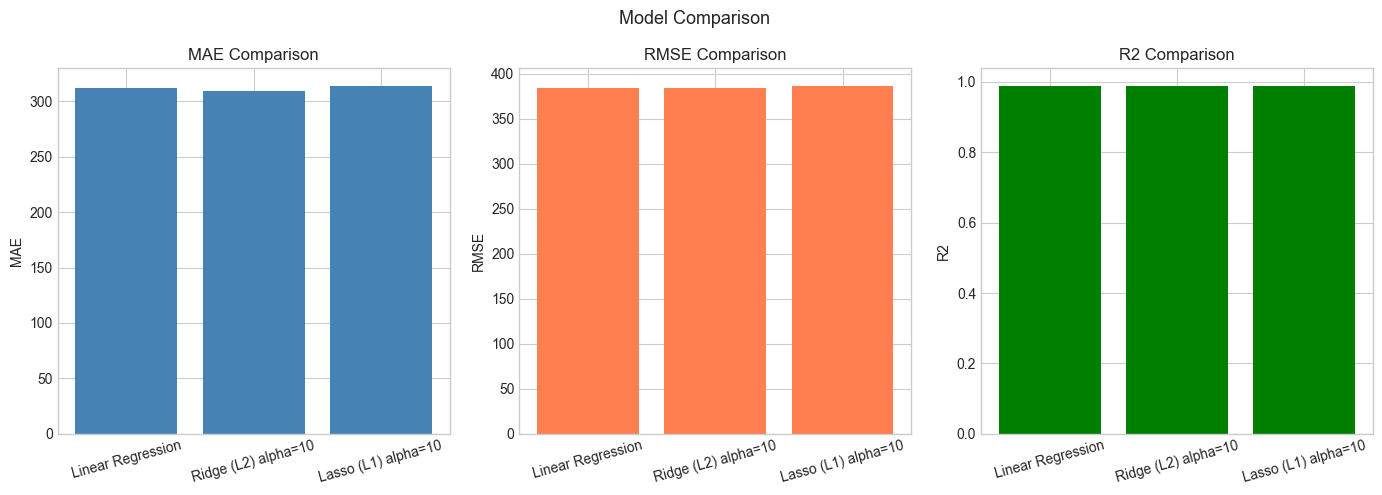

In [134]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['steelblue', 'coral', 'green']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df['Model'], results_df[metric], color=color)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison', fontsize=13)
plt.tight_layout(); plt.show()


## 15. Cross Validation


In [135]:
# TimeSeriesSplit cross validation on full data
tscv = TimeSeriesSplit(n_splits=5)

models_cv = {
    'Linear Regression': lr_pipeline,
    'Ridge': ridge_pipeline,
    'Lasso': lasso_pipeline
}

print("Cross-Validation R² Scores (TimeSeriesSplit, 5 folds):")
print("-" * 55)

for name, pipe in models_cv.items():
    cv_scores = cross_val_score(pipe, X_sorted, y_sorted, cv=tscv, scoring='r2')
    print(f"{name:20} | Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f} | Folds: {np.round(cv_scores, 3)}")


Cross-Validation R² Scores (TimeSeriesSplit, 5 folds):
-------------------------------------------------------
Linear Regression    | Mean: 0.9902 | Std: 0.0008 | Folds: [0.991 0.99  0.991 0.99  0.989]
Ridge                | Mean: 0.9899 | Std: 0.0007 | Folds: [0.99  0.99  0.991 0.99  0.989]
Lasso                | Mean: 0.9904 | Std: 0.0010 | Folds: [0.991 0.99  0.991 0.99  0.989]


## 16. Hyperparameter Tuning


Best alpha:  0.01
Best CV R²:  0.9905


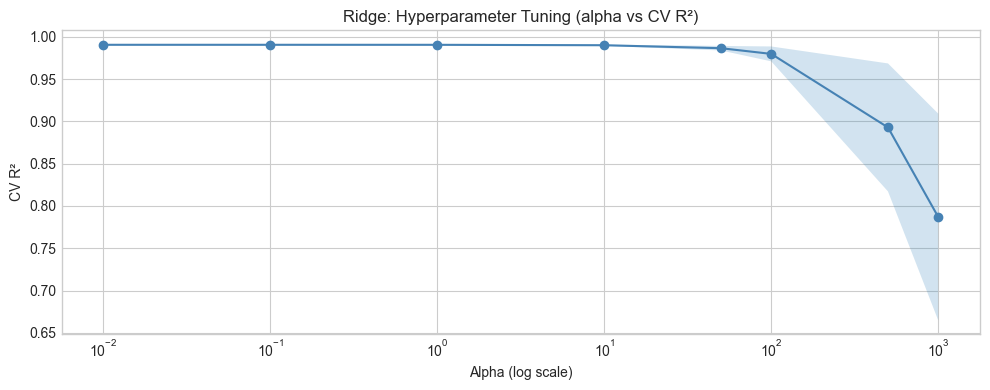

In [136]:
# Tune Ridge alpha
ridge_pipe_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}

grid_search = GridSearchCV(
    ridge_pipe_tune, param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Best alpha:  {grid_search.best_params_['model__alpha']}")
print(f"Best CV R²:  {grid_search.best_score_:.4f}")

# Plot alpha vs CV score
cv_results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 4))
plt.semilogx(param_grid['model__alpha'], cv_results['mean_test_score'], marker='o', color='steelblue')
plt.fill_between(param_grid['model__alpha'],
                 cv_results['mean_test_score'] - cv_results['std_test_score'],
                 cv_results['mean_test_score'] + cv_results['std_test_score'], alpha=0.2)
plt.xlabel('Alpha (log scale)'); plt.ylabel('CV R²')
plt.title('Ridge: Hyperparameter Tuning (alpha vs CV R²)')
plt.tight_layout(); plt.show()


In [137]:
# Evaluate best Ridge model on test set
best_ridge = grid_search.best_estimator_
y_pred_best = best_ridge.predict(X_test)
results.append(evaluate(y_test, y_pred_best, f"Ridge (tuned α={grid_search.best_params_['model__alpha']})"))



  Model: Ridge (tuned α=0.01)
  MAE:   312.21
  RMSE:  384.51
  R²:    0.9891


## 17. Time Series Components

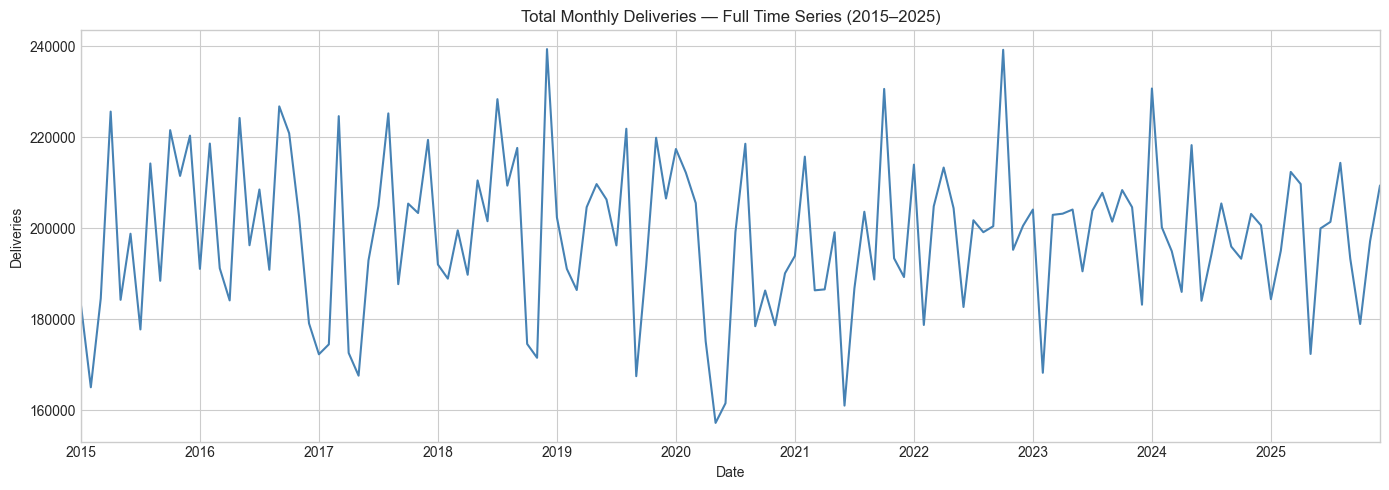

In [138]:
# Aggregate to monthly time series
ts_df = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts_df['Date'] = pd.to_datetime(ts_df[['Year','Month']].assign(day=1))
ts_df = ts_df.sort_values('Date').set_index('Date')['Estimated_Deliveries']

plt.figure(figsize=(14, 5))
ts_df.plot(color='steelblue')
plt.title('Total Monthly Deliveries — Full Time Series (2015–2025)')
plt.ylabel('Deliveries'); plt.xlabel('Date')
plt.tight_layout(); plt.show()


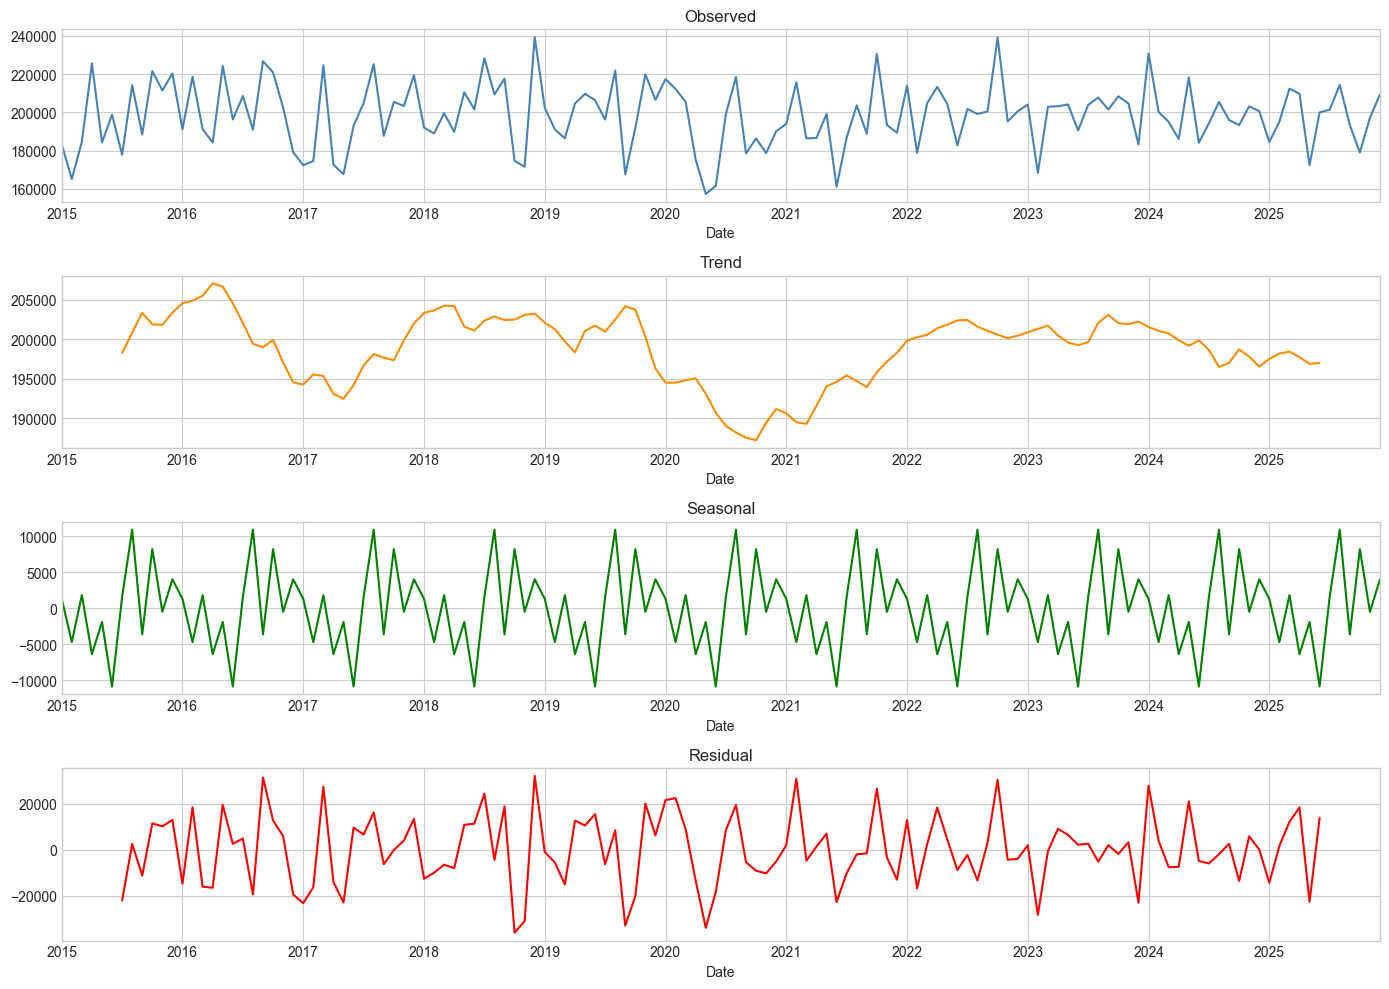

In [139]:
# Decompose time series
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts_df, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='darkorange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
plt.tight_layout(); plt.show()


## 18. Stationarity



ADF Test: Raw Monthly Deliveries
  ADF Statistic: -8.8810
  p-value:       0.0000
  Verdict: Stationary

ADF Test: 1st Differenced Series
  ADF Statistic: -7.0101
  p-value:       0.0000
  Verdict: Stationary


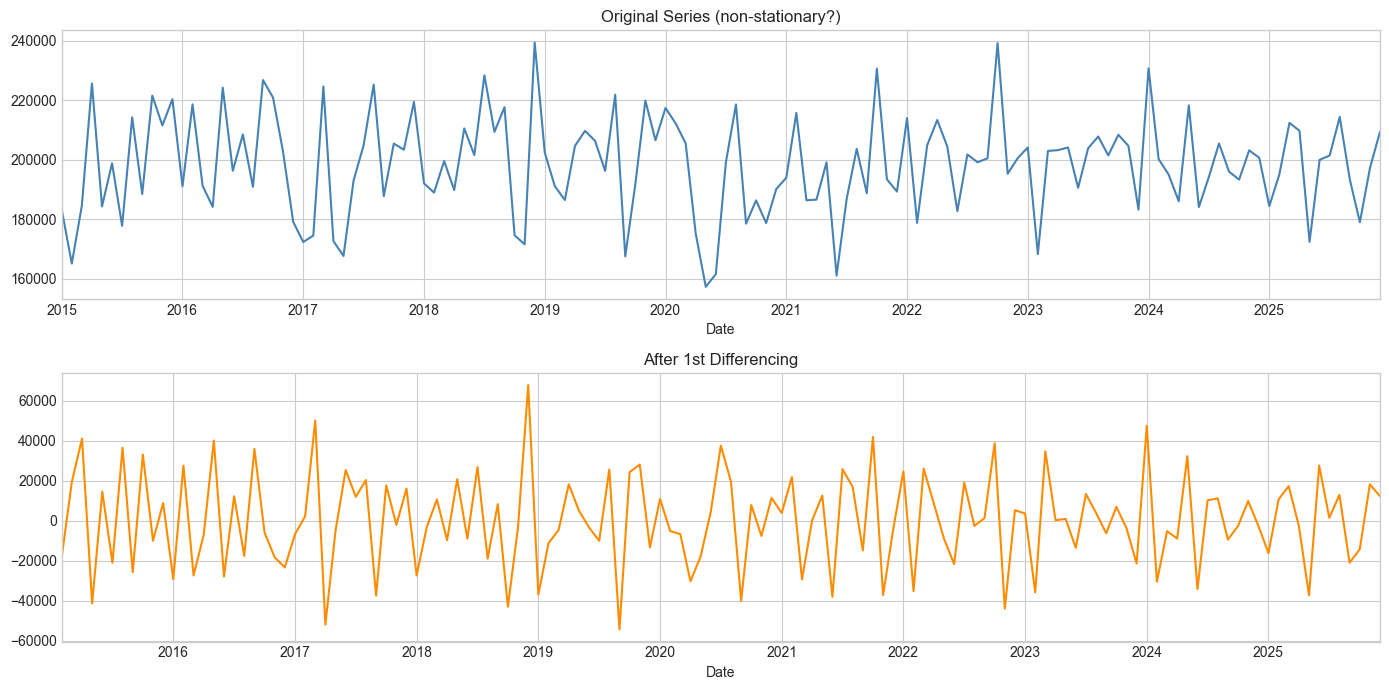

In [140]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\nADF Test: {name}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    print(f"  Verdict: {'Stationary' if result[1] < 0.05 else '❌ Non-Stationary (needs differencing)'}")

adf_test(ts_df, 'Raw Monthly Deliveries')

ts_diff = ts_df.diff().dropna()
adf_test(ts_diff, '1st Differenced Series')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
ts_df.plot(ax=axes[0], title='Original Series (non-stationary?)', color='steelblue')
ts_diff.plot(ax=axes[1], title='After 1st Differencing', color='darkorange')
plt.tight_layout(); plt.show()


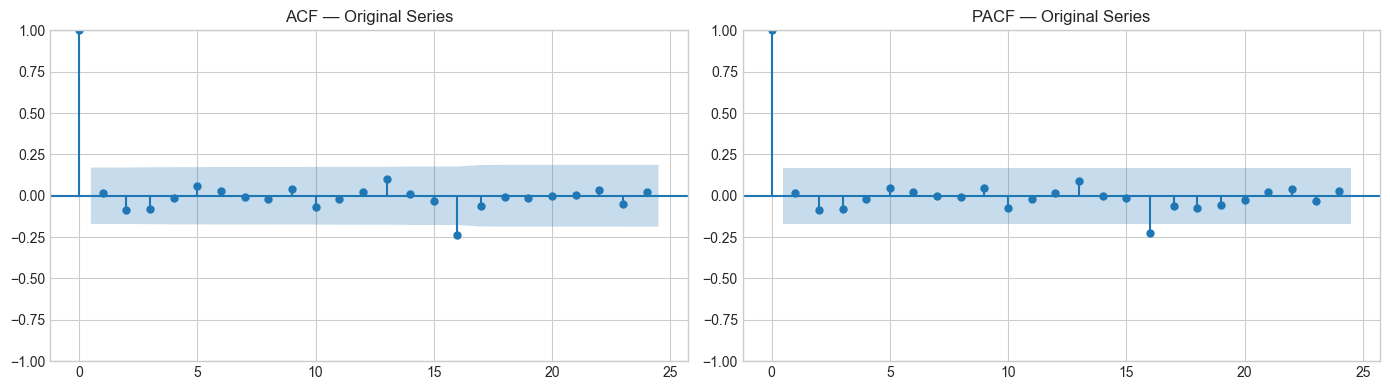

In [141]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_df.dropna(), lags=24, ax=axes[0], title='ACF — Original Series')
plot_pacf(ts_df.dropna(), lags=24, ax=axes[1], title='PACF — Original Series')
plt.tight_layout(); plt.show()


## 19. Lag Features & Rolling Statistics


In [142]:
# Build lag + rolling feature set from the time series
ts_feat = pd.DataFrame({'Deliveries': ts_df})

# Lag features (1, 3, 6, 12 months back)
for lag in [1, 2, 3, 6, 12]:
    ts_feat[f'lag_{lag}'] = ts_feat['Deliveries'].shift(lag)

# Rolling statistics
ts_feat['roll_mean_3']  = ts_feat['Deliveries'].shift(1).rolling(3).mean()
ts_feat['roll_mean_6']  = ts_feat['Deliveries'].shift(1).rolling(6).mean()
ts_feat['roll_std_3']   = ts_feat['Deliveries'].shift(1).rolling(3).std()
ts_feat['roll_mean_12'] = ts_feat['Deliveries'].shift(1).rolling(12).mean()

ts_feat.dropna(inplace=True)
print(f"Feature set shape: {ts_feat.shape}")
print("\nSample:")
print(ts_feat.head(3).to_string())


Feature set shape: (120, 10)

Sample:
            Deliveries     lag_1     lag_2     lag_3     lag_6    lag_12    roll_mean_3    roll_mean_6    roll_std_3   roll_mean_12
Date                                                                                                                               
2016-01-01      191069  220332.0  211490.0  221541.0  177759.0  183180.0  217787.666667  205632.166667   5487.337636  197938.916667
2016-02-01      218600  191069.0  220332.0  211490.0  214223.0  165053.0  207630.333333  207850.500000  15008.449698  198596.333333
2016-03-01      191208  218600.0  191069.0  220332.0  188448.0  184567.0  210000.333333  208580.000000  16417.871127  203058.583333


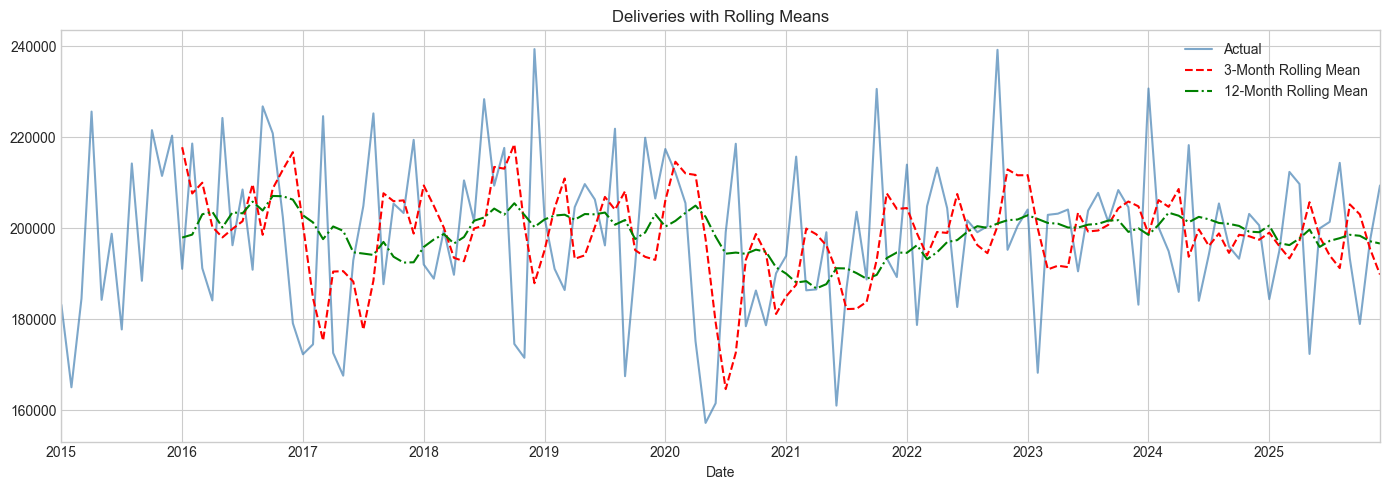

In [143]:
# Visualize rolling statistics
plt.figure(figsize=(14, 5))
ts_df.plot(label='Actual', color='steelblue', alpha=0.7)
ts_feat['roll_mean_3'].plot(label='3-Month Rolling Mean', color='red', linestyle='--')
ts_feat['roll_mean_12'].plot(label='12-Month Rolling Mean', color='green', linestyle='-.')
plt.title('Deliveries with Rolling Means')
plt.legend(); plt.tight_layout(); plt.show()


## 20. Forecasting with Lag Features (Chronological Split)

In [144]:

X_ts = ts_feat.drop('Deliveries', axis=1)
y_ts = ts_feat['Deliveries']


split_idx = int(len(ts_feat) * 0.80)
X_ts_train, X_ts_test = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_ts_train, y_ts_test = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

print(f"TS Train: {X_ts_train.index[0].date()} → {X_ts_train.index[-1].date()}  ({len(X_ts_train)} months)")
print(f"TS Test:  {X_ts_test.index[0].date()}  → {X_ts_test.index[-1].date()}  ({len(X_ts_test)} months)")

ts_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10))
])
ts_pipe.fit(X_ts_train, y_ts_train)
y_ts_pred = ts_pipe.predict(X_ts_test)

ts_mae  = mean_absolute_error(y_ts_test, y_ts_pred)
ts_rmse = np.sqrt(mean_squared_error(y_ts_test, y_ts_pred))
ts_r2   = r2_score(y_ts_test, y_ts_pred)
print(f"\nTime Series Model — MAE: {ts_mae:.0f} | RMSE: {ts_rmse:.0f} | R²: {ts_r2:.4f}")


TS Train: 2016-01-01 → 2023-12-01  (96 months)
TS Test:  2024-01-01  → 2025-12-01  (24 months)

Time Series Model — MAE: 9858 | RMSE: 12957 | R²: -0.0256


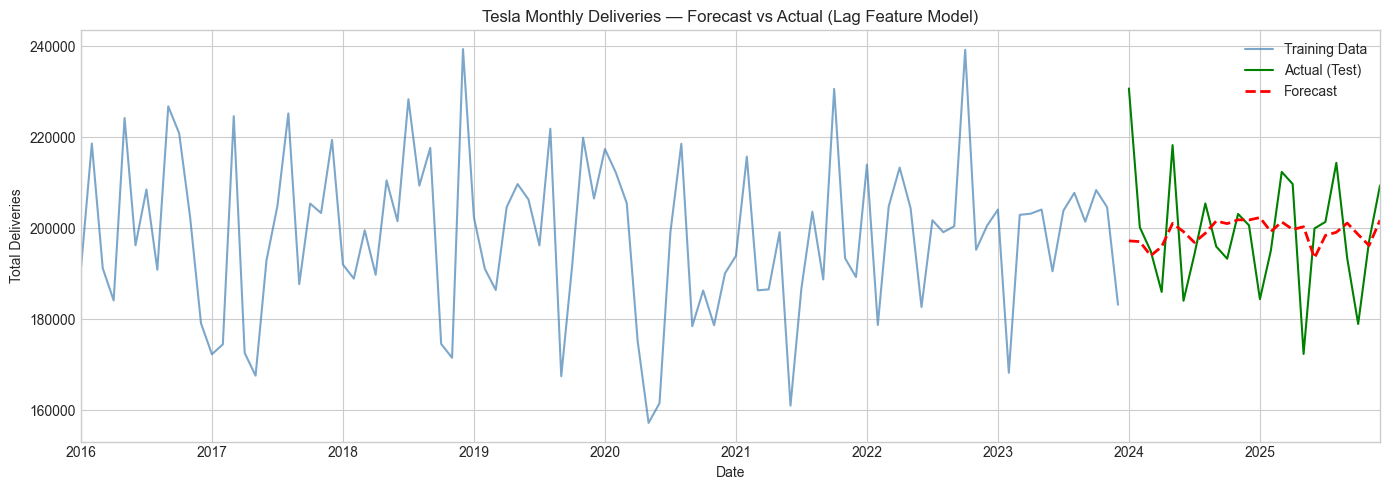

In [145]:
# Plot forecast vs actual
plt.figure(figsize=(14, 5))
y_ts_train.plot(label='Training Data', color='steelblue', alpha=0.7)
y_ts_test.plot(label='Actual (Test)', color='green')
pd.Series(y_ts_pred, index=y_ts_test.index).plot(label='Forecast', color='red', linestyle='--', linewidth=2)
plt.title('Tesla Monthly Deliveries — Forecast vs Actual (Lag Feature Model)')
plt.ylabel('Total Deliveries'); plt.xlabel('Date')
plt.legend(); plt.tight_layout(); plt.show()


## 21. Final Model Comparison & Summary

In [146]:
# All model results summary
all_results = pd.DataFrame(results)
print("\n" + "="*60)
print("       FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(all_results.to_string(index=False))
print("="*60)

best_r2 = all_results.loc[all_results['R2'].idxmax()]
print(f"\n Best Model: {best_r2['Model']}")
print(f"   R²:   {best_r2['R2']:.4f}")
print(f"   MAE:  {best_r2['MAE']:.2f}")
print(f"   RMSE: {best_r2['RMSE']:.2f}")



       FINAL MODEL COMPARISON SUMMARY
               Model        MAE       RMSE       R2
   Linear Regression 312.215063 384.511808 0.989113
 Ridge (L2) alpha=10 309.421502 384.261069 0.989127
 Lasso (L1) alpha=10 314.112124 386.615528 0.988993
Ridge (tuned α=0.01) 312.210634 384.509023 0.989113

 Best Model: Ridge (L2) alpha=10
   R²:   0.9891
   MAE:  309.42
   RMSE: 384.26
